In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.seasonal import seasonal_decompose

GA_RED = '#e32128'

In [61]:
jj = pd.read_csv('../data/jj-sales.csv')
jj.date = pd.to_datetime(jj.date)
jj.set_index('date', inplace=True)
jj.head()

,earnings
date,
1960-01-01,0.71
1960-04-01,0.63
1960-07-01,0.85
1960-10-01,0.44
1961-01-01,0.61


In [62]:
n = jj.shape[0]
jj['t'] = np.arange(n)

In [63]:
X = jj[['t']]
X['t2'] = X.t**2

y = jj['earnings']

lm = LinearRegression()

lm.fit(X, y)

y_pred = lm.predict(X)

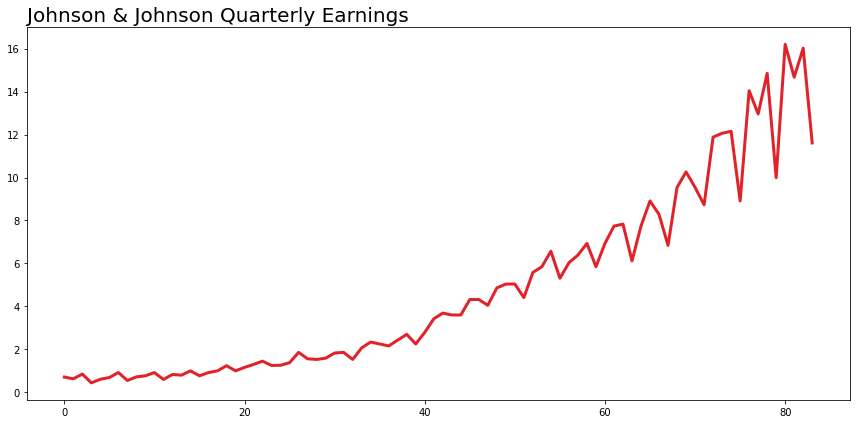

In [64]:
plt.figure(figsize=(12, 6))
plt.plot(jj.t, jj.earnings, c=GA_RED, linewidth=3)
plt.title("Johnson & Johnson Quarterly Earnings", size=20, loc='left')
plt.tight_layout()
plt.savefig('jj-raw.png', dpi=192);
# plt.plot(jj.t, y_pred)

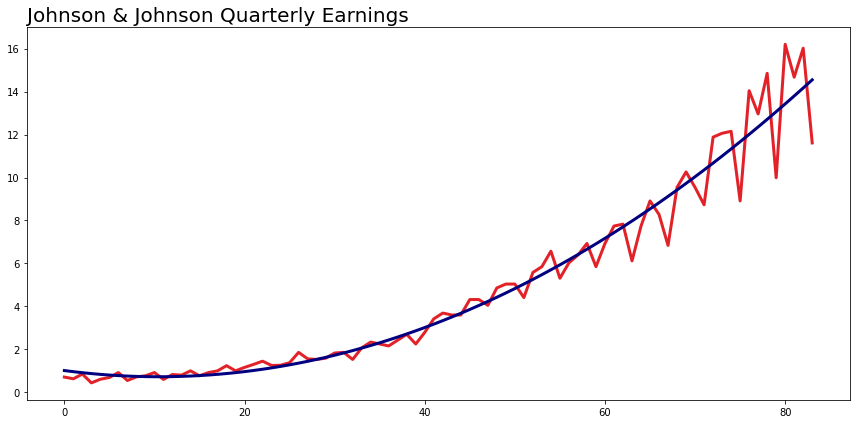

In [65]:
plt.figure(figsize=(12, 6))
plt.plot(jj.t, jj.earnings, c=GA_RED, linewidth=3)
plt.plot(jj.t, y_pred, c='navy', linewidth=3)
plt.title("Johnson & Johnson Quarterly Earnings", size=20, loc='left')
plt.tight_layout()
plt.savefig('jj-ols.png', dpi=192);

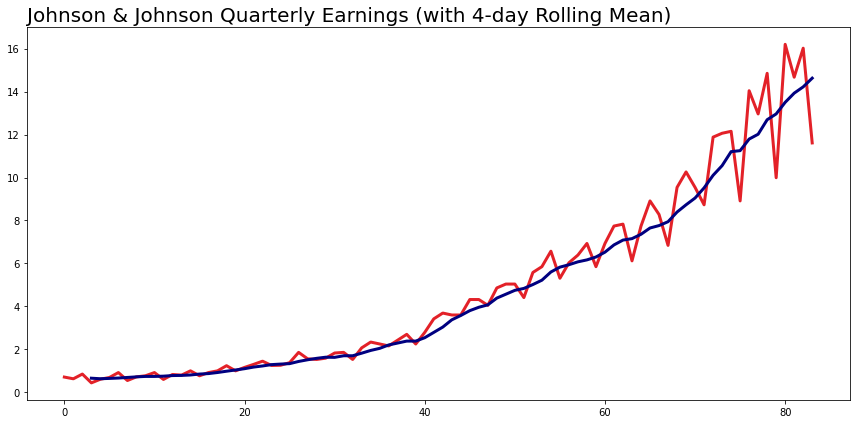

In [66]:
smoother = jj.earnings.rolling(4).mean()

plt.figure(figsize=(12, 6))
plt.plot(jj.t, jj.earnings, c=GA_RED, linewidth=3)
plt.plot(jj.t, smoother, c='navy', linewidth=3)
plt.title("Johnson & Johnson Quarterly Earnings (with 4-day Rolling Mean)", size=20, loc='left')
plt.tight_layout()
plt.savefig('jj-smoother.png', dpi=192)

In [67]:
jj['m'] = y_pred
jj['resid'] = jj['earnings'] - jj['m']
jj['q'] = (jj.index.month - 1) // 3 + 1
w = jj.groupby('q', as_index=False).agg(w = ('resid', 'mean'))
wbar = w.w.mean()
jj_full = jj.reset_index().merge(w, on='q', left_index=True).sort_values('date')
jj_full['s'] = jj_full['w'] - wbar
jj_full.head()

,date,earnings,t,m,resid,q,w,s
0,1960-01-01,0.71,0,1.013624,-0.303624,1,0.233612,0.233612
1,1960-04-01,0.63,1,0.961224,-0.331224,2,0.250104,0.250104
2,1960-07-01,0.85,2,0.914079,-0.064079,3,0.375151,0.375151
3,1960-10-01,0.44,3,0.872189,-0.432189,4,-0.858867,-0.858867
0,1961-01-01,0.61,4,0.835553,-0.225553,1,0.233612,0.233612


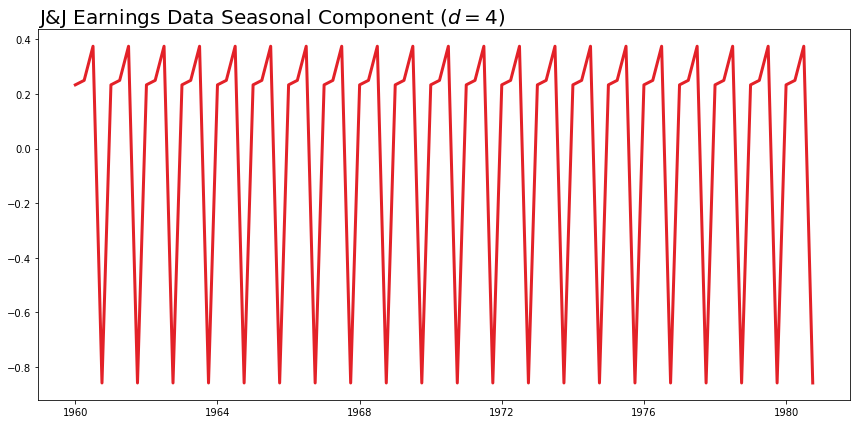

In [68]:
plt.figure(figsize=(12, 6))
plt.title('J&J Earnings Data Seasonal Component ($d = 4$)', size=20, loc='left')
plt.plot(jj_full.date, jj_full.s, c=GA_RED, linewidth=3)
plt.tight_layout()
plt.savefig('jj-seasonal.png', dpi=192);

In [73]:
jj_full['deseasoned'] = jj_full['earnings'] - jj_full['s']
jj_full['noise'] = jj_full['earnings'] - jj_full['m'] - jj_full['s']

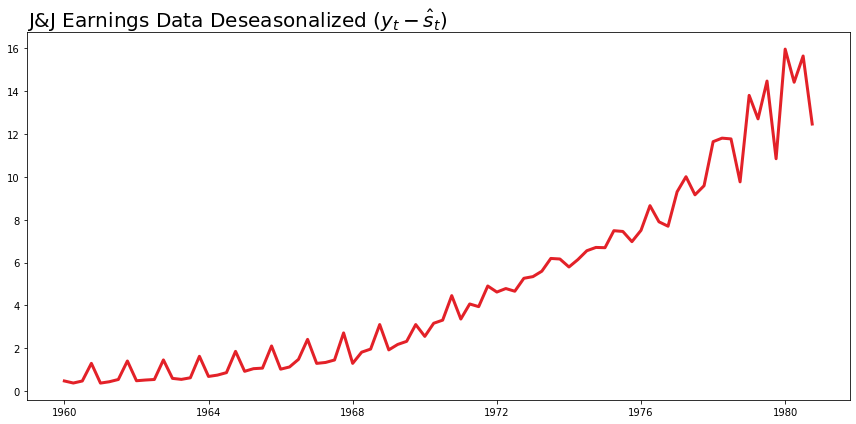

In [90]:
plt.figure(figsize=(12, 6))
plt.title('J&J Earnings Data Deseasonalized ($y_t - \hat s_t$)', size=20, loc='left')
plt.plot(jj_full.date, jj_full.deseasoned, c=GA_RED, linewidth=3)
plt.tight_layout()
plt.savefig('jj-deseasonalized.png', dpi=192);

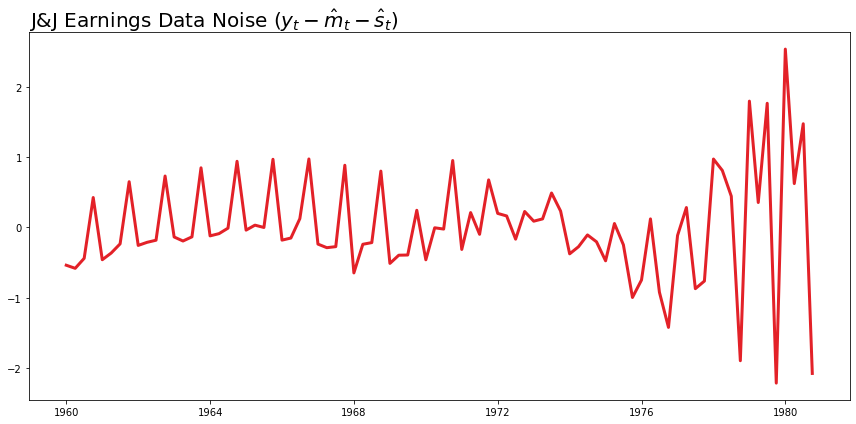

In [93]:
plt.figure(figsize=(12, 6))
plt.title('J&J Earnings Data Noise ($y_t - \hat m_t - \hat s_t$)', size=20, loc='left')
plt.plot(jj_full.date, jj_full.noise, c=GA_RED, linewidth=3)
plt.tight_layout()
plt.savefig('jj-noise.png', dpi=192);

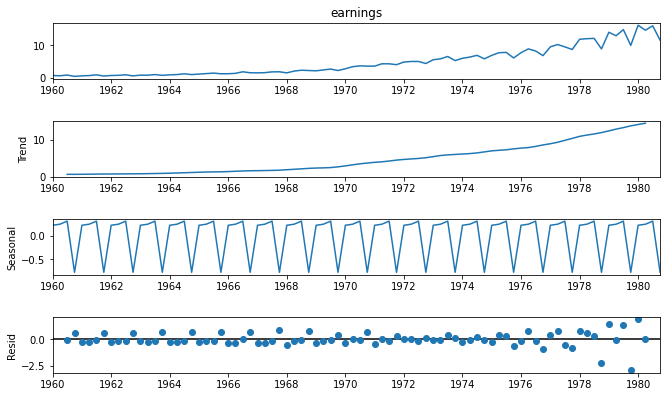

In [92]:
decomp = seasonal_decompose(jj_full.set_index('date')['earnings'], period=4) 
decomp.plot()
plt.gcf().set_size_inches(10, 6)
plt.savefig('jj-decomposed.png', dpi=192)